In [1]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:

from pathlib import Path
import os
import numpy as np
import pandas as pd
import json
from fiftyone import ViewField as F
import matplotlib.pyplot as plt
import numpy as np


## renders plotly properly in a html instance. 
import plotly.io as pio
pio.renderers.default = "notebook"

# init

In [3]:
# load dataset
dataset = fo.load_dataset("dugong")

In [4]:
## load views
nc_view = dataset.load_saved_view('nc')
wp_view = dataset.load_saved_view('wp')

## load saved test view
test_view_seed0 = dataset.load_saved_view('wp_test_s0')
test_view_seed63 = dataset.load_saved_view('wp_test_s63')

# List Evauations


In [73]:
## load the views
#nc_view = dataset.load_saved_view("nc")
#wp_view = dataset.load_saved_view("wp")
## launch session
session = fo.launch_app(dataset,
                        port=5151,
                        auto=False)


Could not connect session, trying again in 10 seconds

Session launched. Run `session.show()` to open the App in a cell output.


In [5]:
dataset.list_evaluations()

['ACLR_p10_SEED0_nms',
 'ACLR_p10_SEED0_raw',
 'ACLR_p25_SEED0_nms',
 'ACLR_p25_SEED0_raw',
 'ACLR_p50_SEED0_nms',
 'ACLR_p50_SEED0_raw',
 'ACLR_p5_SEED0_nms',
 'ACLR_p5_SEED0_raw',
 'ACLR_p75_SEED0_nms',
 'ACLR_p75_SEED0_raw',
 'TEST_SEED0_baseline10',
 'TEST_SEED0_baseline63',
 'TEST_SEED0_baseline72',
 'TEST_SEED63_baseline10',
 'TEST_SEED63_baseline63',
 'TEST_SEED63_baseline72',
 'TEST_SEED72_baseline10',
 'TEST_SEED72_baseline63',
 'TEST_SEED72_baseline72',
 'baseline_SEED0_nms',
 'baseline_SEED0_raw',
 'p100_SEED0_nms',
 'p100_SEED0_raw',
 'p10_SEED0_nms',
 'p10_SEED0_raw',
 'p25_SEED0_nms',
 'p25_SEED0_raw',
 'p50_SEED0_nms',
 'p50_SEED0_raw',
 'p5_SEED0_nms',
 'p5_SEED0_raw',
 'p75_SEED0_nms',
 'p75_SEED0_raw']

In [6]:
eval_of_seed0 = ['ACLR_p10_SEED0_nms',
 'ACLR_p10_SEED0_raw',
 'ACLR_p25_SEED0_nms',
 'ACLR_p25_SEED0_raw',
 'ACLR_p50_SEED0_nms',
 'ACLR_p50_SEED0_raw',
 'ACLR_p5_SEED0_nms',
 'ACLR_p5_SEED0_raw',
 'ACLR_p75_SEED0_nms',
 'ACLR_p75_SEED0_raw',
 'baseline_SEED0_nms',
 'baseline_SEED0_raw',
 'p100_SEED0_nms',
 'p100_SEED0_raw',
 'p10_SEED0_nms',
 'p10_SEED0_raw',
 'p25_SEED0_nms',
 'p25_SEED0_raw',
 'p50_SEED0_nms',
 'p50_SEED0_raw',
 'p5_SEED0_nms',
 'p5_SEED0_raw',
 'p75_SEED0_nms',
 'p75_SEED0_raw']

In [7]:
not_seed0_eval = [eval for eval in dataset.list_evaluations() if eval not in eval_of_seed0]
not_seed0_eval

['TEST_SEED0_baseline10',
 'TEST_SEED0_baseline63',
 'TEST_SEED0_baseline72',
 'TEST_SEED63_baseline10',
 'TEST_SEED63_baseline63',
 'TEST_SEED63_baseline72',
 'TEST_SEED72_baseline10',
 'TEST_SEED72_baseline63',
 'TEST_SEED72_baseline72']

In [10]:
for eval in not_seed0_eval:
    print(f"deleting:{eval}")
    dataset.delete_evaluation(eval)

deleting:ACLR_p10_SEED63_nms
deleting:ACLR_p10_SEED63_raw
deleting:ACLR_p25_SEED63_nms
deleting:ACLR_p25_SEED63_raw
deleting:ACLR_p50_SEED63_nms
deleting:ACLR_p50_SEED63_raw
deleting:ACLR_p5_SEED63_nms
deleting:ACLR_p5_SEED63_raw
deleting:ACLR_p75_SEED63_nms
deleting:ACLR_p75_SEED63_raw
deleting:baseline_SEED63_nms
deleting:baseline_SEED63_raw
deleting:baseline_SEED72_raw
deleting:p100_SEED63_nms
deleting:p100_SEED63_raw
deleting:p10_SEED63_nms
deleting:p10_SEED63_raw
deleting:p25_SEED63_nms
deleting:p25_SEED63_raw
deleting:p50_SEED63_nms
deleting:p50_SEED63_raw
deleting:p5_SEED63_nms
deleting:p5_SEED63_raw
deleting:p75_SEED63_nms
deleting:p75_SEED63_raw


In [16]:
sample = test_view_seed0.first()
det = sample.ground_truth.detections[0]
print(det)  # look for the eval_baseline_SEED0_raw attribute

<Detection: {
    'id': '69add896cfd942e1c6b5c58e',
    'attributes': {},
    'tags': [],
    'label': 'Dugong',
    'bounding_box': [
        0.5018274853801169,
        0.05317982456140351,
        0.01699561403508772,
        0.04276315789473684,
    ],
    'mask': None,
    'mask_path': None,
    'confidence': None,
    'index': None,
    'patch_embeddings': array([-0.5978058 , -0.2737485 , -0.10805661, ...,  0.3813876 ,
           -0.8690382 ,  0.094939  ], shape=(1024,), dtype=float32),
    'dinov3_patch_umap': [67.82942199707031, -16.23343849182129],
    'region': 'WP',
    'subregion': 'MANTASANDY',
    'patch_emb_dinov3_tsne': [67.82942199707031, -16.23343849182129],
    'patch_10expansion_embeddings': array([-0.45114323, -0.08667576,  0.02824171, ...,  0.368037  ,
           -0.8975529 ,  0.04690378], shape=(1024,), dtype=float32),
    'patch_25expansion_embeddings': array([-0.49457765, -0.10710227, -0.00820985, ...,  0.4157841 ,
           -0.8661041 ,  0.05185848], shape=(1

In [15]:
# Samples where at least one GT detection was missed by the baseline
fn_view = test_view_seed0.match(
    F("ground_truth.detections").filter(
        F("baseline_SEED0_raw") == "fn"
    ).length() > 0
)

fn_view

Dataset:     dugong
Media type:  image
Num samples: 20
Sample fields:
    id:                                             fiftyone.core.fields.ObjectIdField
    filepath:                                       fiftyone.core.fields.StringField
    tags:                                           fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                                       fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                                     fiftyone.core.fields.DateTimeField
    last_modified_at:                               fiftyone.core.fields.DateTimeField
    region:                                         fiftyone.core.fields.StringField
    subregion:                                      fiftyone.core.fields.StringField
    mission_name:                                   fiftyone.core.fields.StringField
    sea_state:                                      fiftyone.core.fields.IntFie

In [17]:
session.view = fn_view

In [8]:
def create_eval_key_name(ds_field_name):
    splits = ds_field_name.split('_')

    if 'ACLR' in splits:
        part = splits[3]
        seed = splits[4]
        raw = splits[-1]
        return f"ACLR_p{part}_{seed}_{raw}"
    else:
        part = splits[2]
        seed = splits[3]
        raw = splits[-1]
        return f"p{part}_{seed}_{raw}"


def filter_ops(all_op, 
               nms_or_raw=None, 
               seed_term=None):
    def match(op):
        tokens = op.split('_')

        if nms_or_raw and nms_or_raw not in tokens:
            return False

        if seed_term and seed_term not in tokens:
            return False

        return True

    return [op for op in all_op if match(op)]


def select_evaluation_list(
    all_op,
    nms_or_raw='raw',
    baseline_field='baseline',
    seed_term=None,  
):
    nms_or_raw = nms_or_raw.strip().lower()

    evaluation_list = filter_ops(
        all_op,
        nms_or_raw=nms_or_raw,
        seed_term=seed_term
    )

    models_ft = [
        {
            "pred_field": r,
            "eval_key": create_eval_key_name(r),
        }
        for r in evaluation_list
    ]

    if nms_or_raw not in {"raw", "nms"}:
        raise ValueError(f"Invalid nms_or_raw value: {nms_or_raw}")

    models_ft.append({
        "pred_field": baseline_field,
        "eval_key": f"baseline_{seed_term}_{nms_or_raw}",
    })


    return models_ft

In [11]:
all_op = [
 'NWW_ACLR_partition_10_SEED0_augm_0429_1026_raw',
 'NWW_ACLR_partition_10_SEED0_augm_0429_1026_nms',
 'NWW_ACLR_partition_25_SEED0_augm_0430_0302_raw',
 'NWW_ACLR_partition_25_SEED0_augm_0430_0302_nms',
 'NWW_ACLR_partition_50_SEED0_augm_0430_0357_raw',
 'NWW_ACLR_partition_50_SEED0_augm_0430_0357_nms',
 'NWW_ACLR_partition_5_SEED0_augm_0429_0948_raw',
 'NWW_ACLR_partition_5_SEED0_augm_0429_0948_nms',
 'NWW_ACLR_partition_75_SEED0_augm_0430_0525_raw',
 'NWW_ACLR_partition_75_SEED0_augm_0430_0525_nms',
 'NWW_partition_100_SEED0_augm_0429_0941_raw',
 'NWW_partition_100_SEED0_augm_0429_0941_nms',
 'NWW_partition_10_SEED0_augm_0429_0445_raw',
 'NWW_partition_10_SEED0_augm_0429_0445_nms',
 'NWW_partition_25_SEED0_augm_0429_0531_raw',
 'NWW_partition_25_SEED0_augm_0429_0531_nms',
 'NWW_partition_50_SEED0_augm_0429_0704_raw',
 'NWW_partition_50_SEED0_augm_0429_0704_nms',
 'NWW_partition_5_SEED0_augm_0429_0140_raw',
 'NWW_partition_5_SEED0_augm_0429_0140_nms',
 'NWW_partition_75_SEED0_augm_0429_0941_raw',
 'NWW_partition_75_SEED0_augm_0429_0941_nms',
]


In [9]:
sss_seed0 = select_evaluation_list(
    all_op= all_op,
    nms_or_raw='nms',
     seed_term='SEED0',
    baseline_field='NNN_NC_SEED0_augm_0422_2254conf_50_nms'
)
sss_seed0

[{'pred_field': 'NWW_ACLR_partition_10_SEED0_augm_0429_1026_nms',
  'eval_key': 'ACLR_p10_SEED0_nms'},
 {'pred_field': 'NWW_ACLR_partition_25_SEED0_augm_0430_0302_nms',
  'eval_key': 'ACLR_p25_SEED0_nms'},
 {'pred_field': 'NWW_ACLR_partition_50_SEED0_augm_0430_0357_nms',
  'eval_key': 'ACLR_p50_SEED0_nms'},
 {'pred_field': 'NWW_ACLR_partition_5_SEED0_augm_0429_0948_nms',
  'eval_key': 'ACLR_p5_SEED0_nms'},
 {'pred_field': 'NWW_ACLR_partition_75_SEED0_augm_0430_0525_nms',
  'eval_key': 'ACLR_p75_SEED0_nms'},
 {'pred_field': 'NWW_partition_100_SEED0_augm_0429_0941_nms',
  'eval_key': 'p100_SEED0_nms'},
 {'pred_field': 'NWW_partition_10_SEED0_augm_0429_0445_nms',
  'eval_key': 'p10_SEED0_nms'},
 {'pred_field': 'NWW_partition_25_SEED0_augm_0429_0531_nms',
  'eval_key': 'p25_SEED0_nms'},
 {'pred_field': 'NWW_partition_50_SEED0_augm_0429_0704_nms',
  'eval_key': 'p50_SEED0_nms'},
 {'pred_field': 'NWW_partition_5_SEED0_augm_0429_0140_nms',
  'eval_key': 'p5_SEED0_nms'},
 {'pred_field': 'NWW_p

In [29]:
# check for duplicates
from collections import Counter
pred_fields = [d['pred_field'] for d in sss_seed0]
dups = [k for k, v in Counter(pred_fields).items() if v > 1]

print(dups)

[]


In [ ]:
# DROP DUPLICATE AND LEAVE BASELINE
seen = {}

for item in sss_seed0:
    key = item['pred_field']
    
    if key not in seen:
        seen[key] = item
    else:
        # if duplicate exists, prefer baseline
        if "baseline" in item['eval_key']:
            seen[key] = item
        elif "baseline" not in seen[key]['eval_key']:
            # neither is baseline → keep first (do nothing)
            pass
        # else: existing is baseline → ignore current duplicate

sss_seed0 = list(seen.values())
sss_seed0

In [10]:
# Reload evaluation
results_seed0 = {}
for model in sss_seed0:
    results_seed0[model['eval_key']] = dataset.load_evaluation_results(model['eval_key'])
results_seed0

{'ACLR_p10_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef8017f8e90>,
 'ACLR_p25_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef80168a550>,
 'ACLR_p50_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef801f41590>,
 'ACLR_p5_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef80170c7d0>,
 'ACLR_p75_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef801cb82d0>,
 'p100_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef80170d810>,
 'p10_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef8016f2350>,
 'p25_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef801724550>,
 'p50_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef80170e190>,
 'p5_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef801726050>,
 'p75_SEED0_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7ef80170f9d0>,
 'baseline_SEED0_nms': <fiftyone.utils.ev

# Evaluate what metric to use

if Equal Error Rate of F1 Optimal Threshold

── F1-Optimal ──────────────────────────────────
  Threshold : 0.517
  F1        : 0.796
  Precision : 0.816
  Recall    : 0.777
  TP/FP/FN  : 80 / 18 / 23

── Equal Error Rate ────────────────────────────
  Threshold : 0.010
  FN rate   : 0.223
  FP rate   : 0.192
  Precision : 0.808
  Recall    : 0.777
  TP/FP/FN  : 80 / 19 / 23


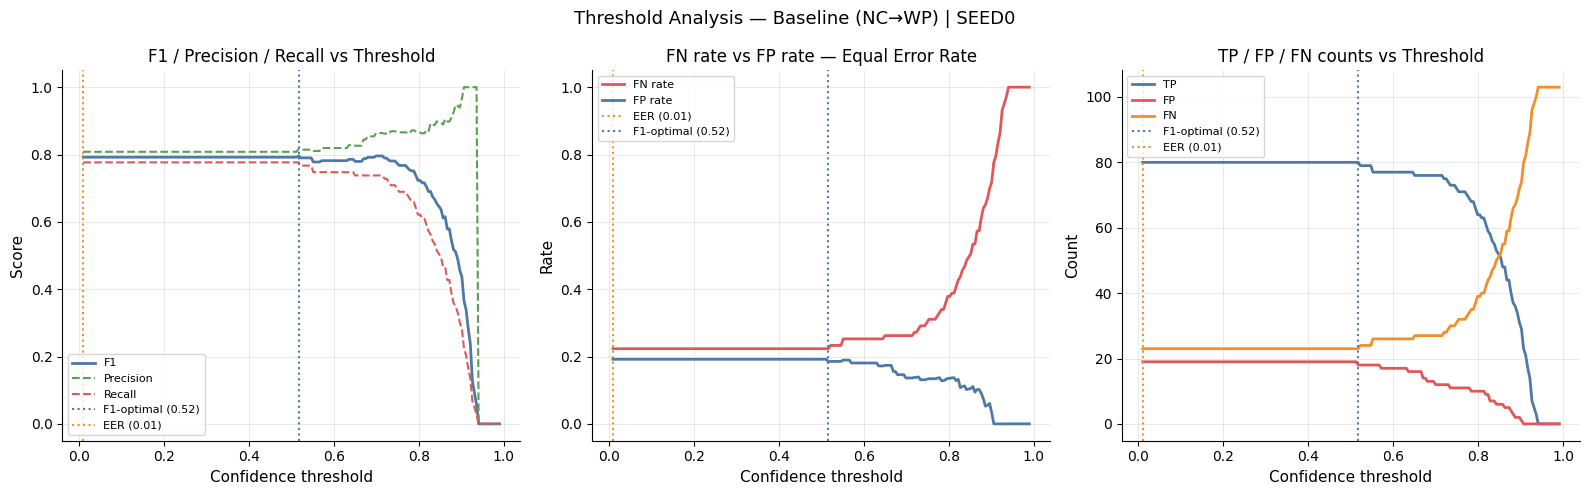

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── Load one evaluation ───────────────────────────────────────────────────────
res    = results_seed0["baseline_SEED0_nms"]
ytrue  = np.array(res.ytrue)
ypred  = np.array(res.ypred)
confs  = np.array([v if v is not None else 0.0 for v in res.confs], dtype=float)
ious   = np.array([v if v is not None else 0.0 for v in res.ious],  dtype=float)

n_gt       = int((ypred == "(none)").sum() + ((ytrue == "Dugong") & (ypred == "Dugong")).sum())
pred_mask  = ypred != "(none)"
thresholds = np.linspace(0.01, 0.99, 200)

# ── Sweep ─────────────────────────────────────────────────────────────────────
records = []
for thresh in thresholds:
    mask = pred_mask & (confs >= thresh)
    tp   = int(((ytrue[mask] == "Dugong") & (ious[mask] >= 0.5)).sum())
    fp   = int((ytrue[mask] == "(none)").sum())
    fn   = int(n_gt - tp)

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    fn_rate   = fn / (n_gt + 1e-9)
    fp_rate   = fp / (mask.sum() + 1e-9) if mask.sum() > 0 else 0.0

    records.append(dict(threshold=thresh, tp=tp, fp=fp, fn=fn,
                        precision=precision, recall=recall,
                        f1=f1, fn_rate=fn_rate, fp_rate=fp_rate))

threshs    = np.array([r0.9074["threshold"]  for r in records])
f1s        = np.array([r["f1"]         for r in records])
precisions = np.array([r["precision"]  for r in records])
recalls    = np.array([r["recall"]     for r in records])
fn_rates   = np.array([r["fn_rate"]    for r in records])
fp_rates   = np.array([r["fp_rate"]    for r in records])
tps        = np.array([r["tp"]         for r in records])
fps        = np.array([r["fp"]         for r in records])
fns        = np.array([r["fn"]         for r in records])

# ── Find optimal thresholds ───────────────────────────────────────────────────
best_f1_idx  = np.argmax(f1s)
best_eer_idx = np.argmin(np.abs(fn_rates - fp_rates))

t_f1  = threshs[best_f1_idx]
t_eer = threshs[best_eer_idx]

print("── F1-Optimal ──────────────────────────────────")
print(f"  Threshold : {t_f1:.3f}")
print(f"  F1        : {f1s[best_f1_idx]:.3f}")
print(f"  Precision : {precisions[best_f1_idx]:.3f}")
print(f"  Recall    : {recalls[best_f1_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_f1_idx]} / {fps[best_f1_idx]} / {fns[best_f1_idx]}")

print("\n── Equal Error Rate ────────────────────────────")
print(f"  Threshold : {t_eer:.3f}")
print(f"  FN rate   : {fn_rates[best_eer_idx]:.3f}")
print(f"  FP rate   : {fp_rates[best_eer_idx]:.3f}")
print(f"  Precision : {precisions[best_eer_idx]:.3f}")
print(f"  Recall    : {recalls[best_eer_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_eer_idx]} / {fps[best_eer_idx]} / {fns[best_eer_idx]}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left — F1 curve
ax = axes[0]
ax.plot(threshs, f1s, color="#4e79a7", linewidth=2, label="F1")
ax.plot(threshs, precisions, color="#59a14f", linewidth=1.5,
        linestyle="--", label="Precision")
ax.plot(threshs, recalls, color="#e15759", linewidth=1.5,
        linestyle="--", label="Recall")
ax.axvline(t_f1, color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("F1 / Precision / Recall vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Middle — EER curve
ax = axes[1]
ax.plot(threshs, fn_rates, color="#e15759", linewidth=2, label="FN rate")
ax.plot(threshs, fp_rates, color="#4e79a7", linewidth=2, label="FP rate")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Rate", fontsize=11)
ax.set_title("FN rate vs FP rate — Equal Error Rate", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Right — TP/FP/FN counts
ax = axes[2]
ax.plot(threshs, tps, color="#4e79a7", linewidth=2, label="TP")
ax.plot(threshs, fps, color="#e15759", linewidth=2, label="FP")
ax.plot(threshs, fns, color="#f28e2b", linewidth=2, label="FN")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("TP / FP / FN counts vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Threshold Analysis — Baseline (NC→WP) | SEED0", fontsize=13)
plt.tight_layout()
plt.savefig("threshold_analysis_baseline_seed0.png", dpi=300, bbox_inches="tight")
plt.show()

── F1-Optimal ──────────────────────────────────
  Threshold : 0.862
  F1        : 0.932
  Precision : 0.932
  Recall    : 0.932
  TP/FP/FN  : 96 / 7 / 7

── Equal Error Rate ────────────────────────────
  Threshold : 0.862
  FN rate   : 0.068
  FP rate   : 0.068
  Precision : 0.932
  Recall    : 0.932
  TP/FP/FN  : 96 / 7 / 7


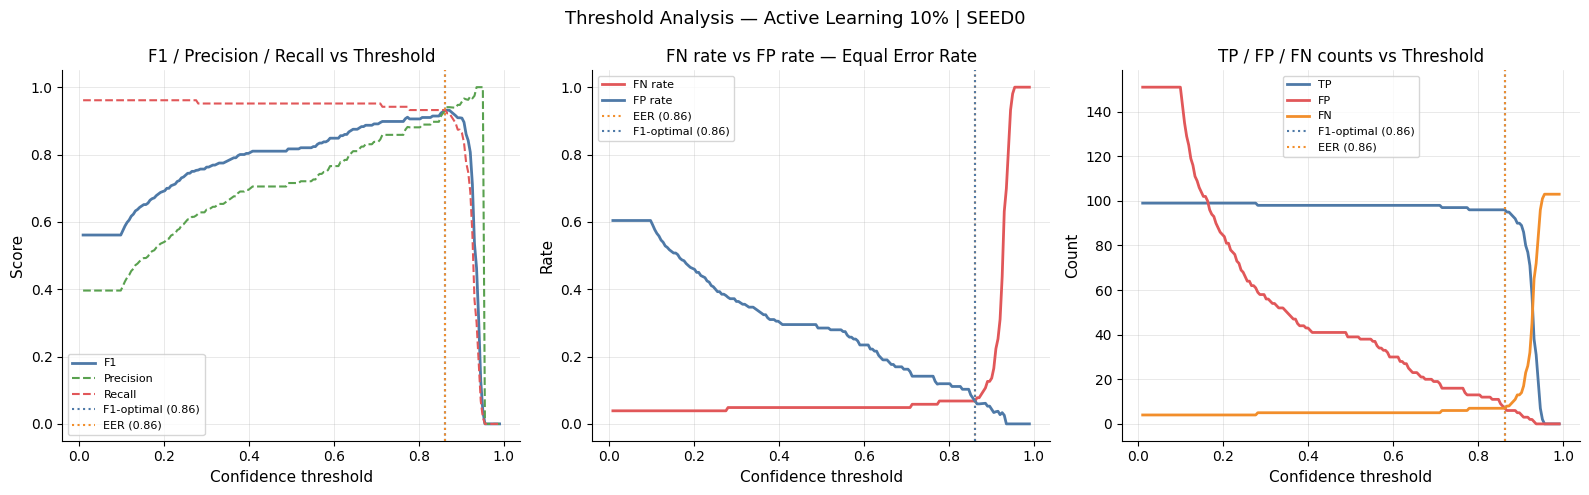

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# ── Load one evaluation ───────────────────────────────────────────────────────
res    = results_seed0["ACLR_p25_SEED0_nms"]
ytrue  = np.array(res.ytrue)
ypred  = np.array(res.ypred)
confs  = np.array([v if v is not None else 0.0 for v in res.confs], dtype=float)
ious   = np.array([v if v is not None else 0.0 for v in res.ious],  dtype=float)

n_gt       = int((ypred == "(none)").sum() + ((ytrue == "Dugong") & (ypred == "Dugong")).sum())
pred_mask  = ypred != "(none)"
thresholds = np.linspace(0.01, 0.99, 200)

# ── Sweep ─────────────────────────────────────────────────────────────────────
records = []
for thresh in thresholds:
    mask = pred_mask & (confs >= thresh)
    tp   = int(((ytrue[mask] == "Dugong") & (ious[mask] >= 0.5)).sum())
    fp   = int((ytrue[mask] == "(none)").sum())
    fn   = int(n_gt - tp)

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    fn_rate   = fn / (n_gt + 1e-9)
    fp_rate   = fp / (mask.sum() + 1e-9) if mask.sum() > 0 else 0.0

    records.append(dict(threshold=thresh, tp=tp, fp=fp, fn=fn,
                        precision=precision, recall=recall,
                        f1=f1, fn_rate=fn_rate, fp_rate=fp_rate))

threshs    = np.array([r["threshold"]  for r in records])
f1s        = np.array([r["f1"]         for r in records])
precisions = np.array([r["precision"]  for r in records])
recalls    = np.array([r["recall"]     for r in records])
fn_rates   = np.array([r["fn_rate"]    for r in records])
fp_rates   = np.array([r["fp_rate"]    for r in records])
tps        = np.array([r["tp"]         for r in records])
fps        = np.array([r["fp"]         for r in records])
fns        = np.array([r["fn"]         for r in records])

# ── Find optimal thresholds ───────────────────────────────────────────────────
best_f1_idx  = np.argmax(f1s)
best_eer_idx = np.argmin(np.abs(fn_rates - fp_rates))

t_f1  = threshs[best_f1_idx]
t_eer = threshs[best_eer_idx]

print("── F1-Optimal ──────────────────────────────────")
print(f"  Threshold : {t_f1:.3f}")
print(f"  F1        : {f1s[best_f1_idx]:.3f}")
print(f"  Precision : {precisions[best_f1_idx]:.3f}")
print(f"  Recall    : {recalls[best_f1_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_f1_idx]} / {fps[best_f1_idx]} / {fns[best_f1_idx]}")

print("\n── Equal Error Rate ────────────────────────────")
print(f"  Threshold : {t_eer:.3f}")
print(f"  FN rate   : {fn_rates[best_eer_idx]:.3f}")
print(f"  FP rate   : {fp_rates[best_eer_idx]:.3f}")
print(f"  Precision : {precisions[best_eer_idx]:.3f}")
print(f"  Recall    : {recalls[best_eer_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_eer_idx]} / {fps[best_eer_idx]} / {fns[best_eer_idx]}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left — F1 curve
ax = axes[0]
ax.plot(threshs, f1s, color="#4e79a7", linewidth=2, label="F1")
ax.plot(threshs, precisions, color="#59a14f", linewidth=1.5,
        linestyle="--", label="Precision")
ax.plot(threshs, recalls, color="#e15759", linewidth=1.5,
        linestyle="--", label="Recall")
ax.axvline(t_f1, color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("F1 / Precision / Recall vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Middle — EER curve
ax = axes[1]
ax.plot(threshs, fn_rates, color="#e15759", linewidth=2, label="FN rate")
ax.plot(threshs, fp_rates, color="#4e79a7", linewidth=2, label="FP rate")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Rate", fontsize=11)
ax.set_title("FN rate vs FP rate — Equal Error Rate", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Right — TP/FP/FN counts
ax = axes[2]
ax.plot(threshs, tps, color="#4e79a7", linewidth=2, label="TP")
ax.plot(threshs, fps, color="#e15759", linewidth=2, label="FP")
ax.plot(threshs, fns, color="#f28e2b", linewidth=2, label="FN")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("TP / FP / FN counts vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Threshold Analysis — Active Learning 10% | SEED0", fontsize=13)
plt.tight_layout()
#plt.savefig("threshold_analysis_baseline_seed0.png", dpi=300, bbox_inches="tight")
plt.show()

# Compute Evaluation

In [30]:
from src.evaluation_metric import extract_all_metrics, select_evaluation_list

In [14]:
## results seed is loaded from evaluation_results ! 

df_metrics = extract_all_metrics(
    results_seed0,
    seed=0
)
df_metrics

Seed 0 done — 12 models processed


,seed,eval_key,mAP,mAR,threshold,f1,precision,recall,tp,fp,fn,n_gt
0,0,ACLR_p10_SEED0_nms,0.735509,0.810680,0.842261,0.925234,0.891892,0.961165,99,12,4,103
1,0,ACLR_p25_SEED0_nms,0.735868,0.802913,0.861960,0.932039,0.932039,0.932039,96,7,7,103
2,0,ACLR_p50_SEED0_nms,0.760379,0.819417,0.857035,0.947368,0.933962,0.961165,99,7,4,103
3,0,ACLR_p5_SEED0_nms,0.703725,0.783495,0.857035,0.907407,0.867257,0.951456,98,15,5,103
4,0,ACLR_p75_SEED0_nms,0.763416,0.831068,0.886583,0.960784,0.970297,0.951456,98,3,5,103
5,0,p100_SEED0_nms,0.759095,0.832039,0.891508,0.942857,0.925234,0.961165,99,8,4,103
6,0,p10_SEED0_nms,0.692694,0.775728,0.916131,0.866310,0.964286,0.786408,81,3,22,103
7,0,p25_SEED0_nms,0.728966,0.795146,0.842261,0.919431,0.898148,0.941748,97,11,6,103
8,0,p50_SEED0_nms,0.757307,0.816505,0.891508,0.927536,0.923077,0.932039,96,8,7,103
9,0,p5_SEED0_nms,0.645778,0.733010,0.778241,0.862385,0.817391,0.912621,94,21,9,103


In [15]:
folder = '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/results/evaluation'
filename = 'evaluation_all_runs_seed0.csv'
df_metrics.to_csv(os.path.join(folder,filename))

In [22]:
## raw
# sss_seed0_raw = select_evaluation_list(
#     all_op= all_op,
#     nms_or_raw='raw',
#      seed_term='SEED0',
#     baseline_field='NNN_NC_SEED0_augm_0422_2254conf_50_raw'
# )
# sss_seed0_raw
## results seed is loaded from evaluation_results ! 
## collect results 
#Reload evaluation
results_seed0 = {}
for model in sss_seed0:
    results_seed0[model['eval_key']] = dataset.load_evaluation_results(model['eval_key'])

df_metrics = extract_all_metrics(
    results_seed0,
    seed=0
)
df_metrics

Seed 0 done — 12 models processed


,seed,eval_key,mAP,mAR,threshold,f1,precision,recall,tp,fp,fn,n_gt
0,0,ACLR_p10_SEED0_raw,0.685724,0.828155,0.906281,0.843602,0.824074,0.864078,89,19,14,103
1,0,ACLR_p25_SEED0_raw,0.705845,0.828155,0.901357,0.853081,0.833333,0.873786,90,18,13,103
2,0,ACLR_p50_SEED0_raw,0.727862,0.839806,0.896432,0.846847,0.789916,0.912621,94,25,9,103
3,0,ACLR_p5_SEED0_raw,0.672854,0.817476,0.901357,0.820276,0.780702,0.864078,89,25,14,103
4,0,ACLR_p75_SEED0_raw,0.722053,0.844660,0.901357,0.850467,0.819820,0.883495,91,20,12,103
5,0,p100_SEED0_raw,0.685135,0.848544,0.906281,0.812227,0.738095,0.902913,93,33,10,103
6,0,p10_SEED0_raw,0.670436,0.819417,0.916131,0.801980,0.818182,0.786408,81,18,22,103
7,0,p25_SEED0_raw,0.701188,0.827184,0.901357,0.829493,0.789474,0.873786,90,24,13,103
8,0,p50_SEED0_raw,0.712989,0.832039,0.901357,0.855856,0.798319,0.922330,95,24,8,103
9,0,p5_SEED0_raw,0.651479,0.801942,0.891508,0.807175,0.750000,0.873786,90,30,13,103


In [21]:

# Run evaluation --- SEED0 RAW
results = {}
for m in sss_seed0_raw:
    results[m["eval_key"]] = test_view_seed0.evaluate_detections(
        m["pred_field"],
        gt_field="ground_truth",
        eval_key=m["eval_key"],
        method="coco",          # COCO-style mAP
        iou=0.5,
        classwise=False,  
        compute_mAP=True,
    )

Evaluating detections...
 100% |█████████████████| 103/103 [650.9ms elapsed, 0s remaining, 158.2 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 103/103 [594.3ms elapsed, 0s remaining, 173.3 samples/s]      
Evaluating detections...
 100% |█████████████████| 103/103 [612.5ms elapsed, 0s remaining, 168.2 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 103/103 [607.5ms elapsed, 0s remaining, 169.5 samples/s]      
Evaluating detections...
 100% |█████████████████| 103/103 [1.2s elapsed, 0s remaining, 83.4 samples/s]          
Performing IoU sweep...
 100% |█████████████████| 103/103 [974.6ms elapsed, 0s remaining, 107.2 samples/s]      
Evaluating detections...
 100% |█████████████████| 103/103 [641.4ms elapsed, 0s remaining, 160.6 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 103/103 [634.8ms elapsed, 0s remaining, 162.2 samples/s]      
Evaluating detections...
 100% |█████████████████| 103/103 [601.5ms elapsed, 0s remaining, 1

In [ ]:
import pandas as pd
from pathlib import Path

def extract_metrics(results_dict: dict, seed: int) -> pd.DataFrame:
    """
    Extract scalar metrics from a dict of COCODetectionResults.
    results_dict: {eval_key: COCODetectionResults}
    """
    rows = []
    for eval_key, res in results_dict.items():
        # Parse eval_key to extract metadata
        # e.g. "eval_NWW_ACLR_p10_S0" → schema=NWW, method=ACLR, partition=10, seed=0
        sweep, best_f1, best_eer = find_optimal_threshold(res)

        rows.append({
            "eval_key":        eval_key,
            "seed":            seed,
            "mAP":             res.mAP(),
            "mAR":             res.mAR(),
            "f1_thresh":       best_f1["threshold"],
            "f1_optimal":      best_f1["f1"],
            "f1_precision":    best_f1["precision"],
            "f1_recall":       best_f1["recall"],
            "f1_tp":           best_f1["tp"],
            "f1_fp":           best_f1["fp"],
            "f1_fn":           best_f1["fn"],
            "eer_thresh":      best_eer["threshold"],
            "eer_fn_rate":     best_eer["fn_rate"],
            "eer_fp_rate":     best_eer["fp_rate"],
        })

    return pd.DataFrame(rows)


# Run for each seed and accumulate
all_metrics = []
for seed, results_dict in [
    (0,  results_seed0),
    (10, results_seed10),
    (63, results_seed63),
]:
    df_seed = extract_metrics(results_dict, seed=seed)
    all_metrics.append(df_seed)

df_all = pd.concat(all_metrics, ignore_index=True)
df_all.to_parquet("evaluation_results_all_seeds.parquet")
print(df_all.head())

# Seed63

In [9]:
check = os.listdir('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63')

In [10]:
check

['NWW_partition_25_SEED63_augm_0510_2337',
 'NWW_ACLR_partition_25_SEED63_augm_0510_2333',
 'NWW_ACLR_partition_5_SEED63_augm_0510_2121',
 'NWW_ACLR_partition_10_SEED63_augm_0510_2124',
 'NWW_partition_5_SEED63_augm_0510_2120',
 'NWW_partition_75_SEED63_augm_0517_1757',
 'NWW_partition_10_SEED63_augm_0510_2120',
 'NWW_ACLR_partition_50_SEED63_augm_0510_2333',
 'NWW_partition_50_SEED63_augm_0511_0035',
 'NWW_ACLR_partition_75_SEED63_augm_0510_2337']

In [11]:
test_view_seed63.distinct('stratify_key')

['WP_FRIWEN_FRIWEN_M19',
 'WP_FRIWEN_FRIWEN_M8',
 'WP_GAM_GAM_M10',
 'WP_MANTASANDY_MANTASANDY_M5',
 'WP_UM_UM_M1']

In [12]:
test_view_seed63

Dataset:     dugong
View name:   wp_test_s63
Media type:  image
Num samples: 104
Sample fields:
    id:                                                  fiftyone.core.fields.ObjectIdField
    filepath:                                            fiftyone.core.fields.StringField
    tags:                                                fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                                            fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                                          fiftyone.core.fields.DateTimeField
    last_modified_at:                                    fiftyone.core.fields.DateTimeField
    region:                                              fiftyone.core.fields.StringField
    subregion:                                           fiftyone.core.fields.StringField
    mission_name:                                        fiftyone.core.fields.StringField
    sea_

In [13]:
## get by seed
sied = 'SEED63'
out_list = []
for line in check:
    for word in line.split('_'):
        if sied == word:
            out_list.append(line)
        else:
            pass

out_list

['NWW_partition_25_SEED63_augm_0510_2337',
 'NWW_ACLR_partition_25_SEED63_augm_0510_2333',
 'NWW_ACLR_partition_5_SEED63_augm_0510_2121',
 'NWW_ACLR_partition_10_SEED63_augm_0510_2124',
 'NWW_partition_5_SEED63_augm_0510_2120',
 'NWW_partition_75_SEED63_augm_0517_1757',
 'NWW_partition_10_SEED63_augm_0510_2120',
 'NWW_ACLR_partition_50_SEED63_augm_0510_2333',
 'NWW_partition_50_SEED63_augm_0511_0035',
 'NWW_ACLR_partition_75_SEED63_augm_0510_2337']

In [14]:
final_out_list = ['NWW_partition_25_SEED63_augm_0510_2337',
 'NWW_ACLR_partition_25_SEED63_augm_0510_2333',
 'NWW_ACLR_partition_5_SEED63_augm_0510_2121',
 'NWW_ACLR_partition_10_SEED63_augm_0510_2124',
 'NWW_partition_5_SEED63_augm_0510_2120',
 'NWW_partition_75_SEED63_augm_0517_1757',
 'NWW_partition_10_SEED63_augm_0510_2120',
 'NWW_ACLR_partition_50_SEED63_augm_0510_2333',
 'NWW_partition_50_SEED63_augm_0511_0035',
 'NWW_ACLR_partition_75_SEED63_augm_0510_2337']

In [15]:
## reconstruct into fiftyone
root_folder_ = '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63'

list_folders_jj = [os.path.join(root_folder_,l) for l in final_out_list]
list_folders_jj

['/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63/NWW_partition_25_SEED63_augm_0510_2337',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63/NWW_ACLR_partition_25_SEED63_augm_0510_2333',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63/NWW_ACLR_partition_5_SEED63_augm_0510_2121',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63/NWW_ACLR_partition_10_SEED63_augm_0510_2124',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63/NWW_partition_5_SEED63_augm_0510_2120',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63/NWW_partition_75_SEED63_augm_0517_1757',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63/NWW_partition_10_SEED63_augm_0510_2120',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63/NWW_ACLR_partition_50_SEED63_augm_0510_2333',
 '/share/home/e2406743

In [16]:
## import function 
from reconstruct import reconstruct_predictions, reconstruct_and_nms

In [17]:
def extract_stem(path):
    return Path(path).stem

# import func and reconstruct 

for prediction in list_folders_jj:
    name_field = extract_stem(prediction)
    ## apply non-maximumm supression
    reconstruct_and_nms(
        dataset=dataset,
        predictions_dir=prediction,
        field_name=name_field,
        tile_size=640
    )

2026-05-17 21:39:39.356 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63/NWW_partition_25_SEED63_augm_0510_2337'
2026-05-17 21:39:39.443 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 336 JSONs → 104 unique sample stems
2026-05-17 21:39:39.446 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 104 / 2755 samples to JSONs
2026-05-17 21:39:44.941 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NWW_partition_25_SEED63_augm_0510_2337_raw' 
2026-05-17 21:39:44.945 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.35) → field 'NWW_partition_25_SEED63_augm_0510_2337_nms'


 100% |█████████████████| 104/104 [4.6s elapsed, 0s remaining, 30.9 samples/s]      


2026-05-17 21:39:49.605 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NWW_partition_25_SEED63_augm_0510_2337_nms' saved | detections before NMS: 267 | after NMS: 198 | suppressed: 69 (25.8%)
2026-05-17 21:39:49.606 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63/NWW_ACLR_partition_25_SEED63_augm_0510_2333'
2026-05-17 21:39:49.637 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 336 JSONs → 104 unique sample stems
2026-05-17 21:39:49.639 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 104 / 2755 samples to JSONs
2026-05-17 21:39:53.978 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NWW_ACLR_partition_25_SEED63_augm_0510_2333_raw' 
2026-05-17 21:39:53.982 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.35) → field 'NWW_ACLR_

 100% |█████████████████| 104/104 [4.6s elapsed, 0s remaining, 24.9 samples/s]      


2026-05-17 21:39:58.572 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NWW_ACLR_partition_25_SEED63_augm_0510_2333_nms' saved | detections before NMS: 296 | after NMS: 222 | suppressed: 74 (25.0%)
2026-05-17 21:39:58.573 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63/NWW_ACLR_partition_5_SEED63_augm_0510_2121'
2026-05-17 21:39:58.604 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 336 JSONs → 104 unique sample stems
2026-05-17 21:39:58.607 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 104 / 2755 samples to JSONs
2026-05-17 21:40:03.395 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NWW_ACLR_partition_5_SEED63_augm_0510_2121_raw' 
2026-05-17 21:40:03.400 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.35) → field 'NWW_AC

...

2026-05-17 21:40:51.407 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NWW_ACLR_partition_50_SEED63_augm_0510_2333_nms' saved | detections before NMS: 331 | after NMS: 244 | suppressed: 87 (26.3%)
2026-05-17 21:40:51.408 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63/NWW_partition_50_SEED63_augm_0511_0035'
2026-05-17 21:40:51.444 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 336 JSONs → 104 unique sample stems
2026-05-17 21:40:51.446 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 104 / 2755 samples to JSONs
2026-05-17 21:40:56.142 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NWW_partition_50_SEED63_augm_0511_0035_raw' 
2026-05-17 21:40:56.144 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.35) → field 'NWW_partition_

 100% |█████████████████| 104/104 [5.2s elapsed, 0s remaining, 18.3 samples/s]      


2026-05-17 21:41:01.376 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NWW_partition_50_SEED63_augm_0511_0035_nms' saved | detections before NMS: 302 | after NMS: 221 | suppressed: 81 (26.8%)
2026-05-17 21:41:01.377 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed63/NWW_ACLR_partition_75_SEED63_augm_0510_2337'
2026-05-17 21:41:01.406 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 336 JSONs → 104 unique sample stems
2026-05-17 21:41:01.408 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 104 / 2755 samples to JSONs
2026-05-17 21:41:06.225 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NWW_ACLR_partition_75_SEED63_augm_0510_2337_raw' 
2026-05-17 21:41:06.227 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.35) → field 'NWW_ACLR_

 100% |█████████████████| 104/104 [3.9s elapsed, 0s remaining, 23.1 samples/s]      


2026-05-17 21:41:10.102 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NWW_ACLR_partition_75_SEED63_augm_0510_2337_nms' saved | detections before NMS: 311 | after NMS: 228 | suppressed: 83 (26.7%)


In [18]:
which_seed = "_SEED63_"
all_fields = dataset.get_field_schema().keys()
seed63_fields = [f for f in all_fields if which_seed in f]

seed63_fields_raw = [f for f in seed63_fields if "raw" in f]
seed63_fields_nms = [f for f in seed63_fields if "nms" in f]
seed63_fields_excluding_evaluation = [
    f for f in seed63_fields if not any(x in f for x in ['tp', 'tn', 'fp','fn'])
]
seed63_fields_excluding_evaluation

['NNN_NC_SEED63_augm_0510_1843_conf_10_raw',
 'NNN_NC_SEED63_augm_0510_1843_conf_10_nms',
 'NWW_ACLR_partition_10_SEED63_augm_0510_2124_raw',
 'NWW_ACLR_partition_10_SEED63_augm_0510_2124_nms',
 'NWW_ACLR_partition_25_SEED63_augm_0510_2333_raw',
 'NWW_ACLR_partition_25_SEED63_augm_0510_2333_nms',
 'NWW_ACLR_partition_50_SEED63_augm_0510_2333_raw',
 'NWW_ACLR_partition_50_SEED63_augm_0510_2333_nms',
 'NWW_ACLR_partition_5_SEED63_augm_0510_2121_raw',
 'NWW_ACLR_partition_5_SEED63_augm_0510_2121_nms',
 'NWW_ACLR_partition_75_SEED63_augm_0510_2337_raw',
 'NWW_ACLR_partition_75_SEED63_augm_0510_2337_nms',
 'NWW_partition_10_SEED63_augm_0510_2120_raw',
 'NWW_partition_10_SEED63_augm_0510_2120_nms',
 'NWW_partition_25_SEED63_augm_0510_2337_raw',
 'NWW_partition_25_SEED63_augm_0510_2337_nms',
 'NWW_partition_50_SEED63_augm_0511_0035_raw',
 'NWW_partition_50_SEED63_augm_0511_0035_nms',
 'NWW_partition_5_SEED63_augm_0510_2120_raw',
 'NWW_partition_5_SEED63_augm_0510_2120_nms',
 'NNN_NC_SEED63_ba

In [ ]:
# for ff in seed63_fields_excluding_evaluation:
#     print(f"deleting:{ff}")
#     dataset.delete_sample_fields(ff)

deleting:NNN_NC_SEED63_augm_0506_0140_conf_10_raw
deleting:NNN_NC_SEED63_augm_0506_0140_conf_10_nms
deleting:NWW_ACLR_partition_10_SEED63_augm_0506_1121_raw
deleting:NWW_ACLR_partition_10_SEED63_augm_0506_1121_nms
deleting:NWW_ACLR_partition_25_SEED63_augm_0507_0329_raw
deleting:NWW_ACLR_partition_25_SEED63_augm_0507_0329_nms
deleting:NWW_ACLR_partition_50_SEED63_augm_0507_0409_raw
deleting:NWW_ACLR_partition_50_SEED63_augm_0507_0409_nms
deleting:NWW_ACLR_partition_5_SEED63_augm_0506_1048_raw
deleting:NWW_ACLR_partition_5_SEED63_augm_0506_1048_nms
deleting:NWW_ACLR_partition_75_SEED63_augm_0507_0600_raw
deleting:NWW_ACLR_partition_75_SEED63_augm_0507_0600_nms
deleting:NWW_partition_100_SEED63_augm_0506_1353_raw
deleting:NWW_partition_100_SEED63_augm_0506_1353_nms
deleting:NWW_partition_10_SEED63_augm_0506_0955_raw
deleting:NWW_partition_10_SEED63_augm_0506_0955_nms
deleting:NWW_partition_25_SEED63_augm_0506_1309_raw
deleting:NWW_partition_25_SEED63_augm_0506_1309_nms
deleting:NWW_parti

In [19]:
sss_seed63 = select_evaluation_list(
    all_op= seed63_fields_excluding_evaluation,
    nms_or_raw='nms',
     seed_term='SEED63',
    baseline_field='NNN_NC_SEED63_augm_0510_1843_conf_10_nms'
)
sss_seed63

[{'pred_field': 'NNN_NC_SEED63_augm_0510_1843_conf_10_nms',
  'eval_key': 'pSEED63_augm_nms'},
 {'pred_field': 'NWW_ACLR_partition_10_SEED63_augm_0510_2124_nms',
  'eval_key': 'ACLR_p10_SEED63_nms'},
 {'pred_field': 'NWW_ACLR_partition_25_SEED63_augm_0510_2333_nms',
  'eval_key': 'ACLR_p25_SEED63_nms'},
 {'pred_field': 'NWW_ACLR_partition_50_SEED63_augm_0510_2333_nms',
  'eval_key': 'ACLR_p50_SEED63_nms'},
 {'pred_field': 'NWW_ACLR_partition_5_SEED63_augm_0510_2121_nms',
  'eval_key': 'ACLR_p5_SEED63_nms'},
 {'pred_field': 'NWW_ACLR_partition_75_SEED63_augm_0510_2337_nms',
  'eval_key': 'ACLR_p75_SEED63_nms'},
 {'pred_field': 'NWW_partition_10_SEED63_augm_0510_2120_nms',
  'eval_key': 'p10_SEED63_nms'},
 {'pred_field': 'NWW_partition_25_SEED63_augm_0510_2337_nms',
  'eval_key': 'p25_SEED63_nms'},
 {'pred_field': 'NWW_partition_50_SEED63_augm_0511_0035_nms',
  'eval_key': 'p50_SEED63_nms'},
 {'pred_field': 'NWW_partition_5_SEED63_augm_0510_2120_nms',
  'eval_key': 'p5_SEED63_nms'},
 {'p

In [22]:
# check for duplicates
from collections import Counter
pred_fields = [d['pred_field'] for d in sss_seed63]
dups = [k for k, v in Counter(pred_fields).items() if v > 1]

print(f"WARNING: THERE IS DUPLICATED FIELD: {dups}")

In [21]:
# DROP DUPLICATE AND LEAVE BASELINE
seen = {}

for item in sss_seed63:
    key = item['pred_field']
    
    if key not in seen:
        seen[key] = item
    else:
        # if duplicate exists, prefer baseline
        if "baseline" in item['eval_key']:
            seen[key] = item
        elif "baseline" not in seen[key]['eval_key']:
            # neither is baseline → keep first (do nothing)
            pass
        # else: existing is baseline → ignore current duplicate

sss_seed63 = list(seen.values())
sss_seed63

[{'pred_field': 'NNN_NC_SEED63_augm_0510_1843_conf_10_nms',
  'eval_key': 'baseline_SEED63_nms'},
 {'pred_field': 'NWW_ACLR_partition_10_SEED63_augm_0510_2124_nms',
  'eval_key': 'ACLR_p10_SEED63_nms'},
 {'pred_field': 'NWW_ACLR_partition_25_SEED63_augm_0510_2333_nms',
  'eval_key': 'ACLR_p25_SEED63_nms'},
 {'pred_field': 'NWW_ACLR_partition_50_SEED63_augm_0510_2333_nms',
  'eval_key': 'ACLR_p50_SEED63_nms'},
 {'pred_field': 'NWW_ACLR_partition_5_SEED63_augm_0510_2121_nms',
  'eval_key': 'ACLR_p5_SEED63_nms'},
 {'pred_field': 'NWW_ACLR_partition_75_SEED63_augm_0510_2337_nms',
  'eval_key': 'ACLR_p75_SEED63_nms'},
 {'pred_field': 'NWW_partition_10_SEED63_augm_0510_2120_nms',
  'eval_key': 'p10_SEED63_nms'},
 {'pred_field': 'NWW_partition_25_SEED63_augm_0510_2337_nms',
  'eval_key': 'p25_SEED63_nms'},
 {'pred_field': 'NWW_partition_50_SEED63_augm_0511_0035_nms',
  'eval_key': 'p50_SEED63_nms'},
 {'pred_field': 'NWW_partition_5_SEED63_augm_0510_2120_nms',
  'eval_key': 'p5_SEED63_nms'},
 

In [26]:
sss_seed63 = [
    {'pred_field': 'NNN_NC_SEED63_augm_0510_1843_conf_10_nms',
  'eval_key': 'baseline_SEED63_nms'},
 {'pred_field': 'NWW_ACLR_partition_10_SEED63_augm_0510_2124_nms',
  'eval_key': 'ACLR_p10_SEED63_nms'},
 {'pred_field': 'NWW_ACLR_partition_25_SEED63_augm_0510_2333_nms',
  'eval_key': 'ACLR_p25_SEED63_nms'},
 {'pred_field': 'NWW_ACLR_partition_50_SEED63_augm_0510_2333_nms',
  'eval_key': 'ACLR_p50_SEED63_nms'},
 {'pred_field': 'NWW_ACLR_partition_5_SEED63_augm_0510_2121_nms',
  'eval_key': 'ACLR_p5_SEED63_nms'},
 {'pred_field': 'NWW_ACLR_partition_75_SEED63_augm_0510_2337_nms',
  'eval_key': 'ACLR_p75_SEED63_nms'},
 {'pred_field': 'NWW_partition_10_SEED63_augm_0510_2120_nms',
  'eval_key': 'p10_SEED63_nms'},
 {'pred_field': 'NWW_partition_25_SEED63_augm_0510_2337_nms',
  'eval_key': 'p25_SEED63_nms'},
 {'pred_field': 'NWW_partition_50_SEED63_augm_0511_0035_nms',
  'eval_key': 'p50_SEED63_nms'},
 {'pred_field': 'NWW_partition_5_SEED63_augm_0510_2120_nms',
  'eval_key': 'p5_SEED63_nms'},
 {'pred_field': 'NWW_partition_75_SEED63_augm_0517_1757_nms',
  'eval_key': 'p75_SEED63_nms'}
  ]

In [11]:
dataset.list_evaluations()

['ACLR_p10_SEED0_nms',
 'ACLR_p10_SEED0_raw',
 'ACLR_p10_SEED63_nms',
 'ACLR_p25_SEED0_nms',
 'ACLR_p25_SEED0_raw',
 'ACLR_p25_SEED63_nms',
 'ACLR_p50_SEED0_nms',
 'ACLR_p50_SEED0_raw',
 'ACLR_p50_SEED63_nms',
 'ACLR_p5_SEED0_nms',
 'ACLR_p5_SEED0_raw',
 'ACLR_p5_SEED63_nms',
 'ACLR_p75_SEED0_nms',
 'ACLR_p75_SEED0_raw',
 'ACLR_p75_SEED63_nms',
 'baseline_SEED0_nms',
 'baseline_SEED0_raw',
 'baseline_SEED63_nms',
 'baseline_SEED63_raw',
 'p100_SEED0_nms',
 'p100_SEED0_raw',
 'p10_SEED0_nms',
 'p10_SEED0_raw',
 'p10_SEED63_nms',
 'p25_SEED0_nms',
 'p25_SEED0_raw',
 'p25_SEED63_nms',
 'p50_SEED0_nms',
 'p50_SEED0_raw',
 'p50_SEED63_nms',
 'p5_SEED0_nms',
 'p5_SEED0_raw',
 'p5_SEED63_nms',
 'p75_SEED0_nms',
 'p75_SEED0_raw']

In [23]:
# compute evaluations 
# --- Run evaluations ---
results = {}
for m in sss_seed63:
    results[m["eval_key"]] = test_view_seed63.evaluate_detections(
        m["pred_field"],
        gt_field="ground_truth",
        eval_key=m["eval_key"],
        method="coco",          # COCO-style mAP
        iou=0.5,
        classwise=False,        # single class (dugong), no need to enforce classwise
        compute_mAP=True,
    )

Evaluating detections...
 100% |█████████████████| 104/104 [597.5ms elapsed, 0s remaining, 174.1 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 104/104 [470.9ms elapsed, 0s remaining, 220.9 samples/s]      
Evaluating detections...
 100% |█████████████████| 104/104 [629.8ms elapsed, 0s remaining, 165.1 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 104/104 [805.0ms elapsed, 0s remaining, 129.2 samples/s]      
Evaluating detections...
 100% |█████████████████| 104/104 [682.5ms elapsed, 0s remaining, 152.4 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 104/104 [566.0ms elapsed, 0s remaining, 183.7 samples/s]      
Evaluating detections...
 100% |█████████████████| 104/104 [1.2s elapsed, 0s remaining, 84.3 samples/s]          
Performing IoU sweep...
 100% |█████████████████| 104/104 [925.1ms elapsed, 0s remaining, 112.4 samples/s]      
Evaluating detections...
 100% |█████████████████| 104/104 [671.4ms elapsed, 0s remaining, 1

In [27]:
## reload evaluations 
# Reload evaluation
results_seed63 = {}
for model in sss_seed63:
    results_seed63[model['eval_key']] = dataset.load_evaluation_results(model['eval_key'])
results_seed63

{'baseline_SEED63_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b55013690>,
 'ACLR_p10_SEED63_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b553dc450>,
 'ACLR_p25_SEED63_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3c989e1a90>,
 'ACLR_p50_SEED63_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3c98b43650>,
 'ACLR_p5_SEED63_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b54ababd0>,
 'ACLR_p75_SEED63_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3c98ade050>,
 'p10_SEED63_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b54901b50>,
 'p25_SEED63_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b552e4710>,
 'p50_SEED63_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b54c45210>,
 'p5_SEED63_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b553ded10>,
 'p75_SEED63_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b54900610>}

── F1-Optimal ──────────────────────────────────
  Threshold : 0.104
  F1        : 0.447
  Precision : 0.530
  Recall    : 0.386
  TP/FP/FN  : 61 / 54 / 97

── Equal Error Rate ────────────────────────────
  Threshold : 0.010
  FN rate   : 0.614
  FP rate   : 0.474
  Precision : 0.526
  Recall    : 0.386
  TP/FP/FN  : 61 / 55 / 97


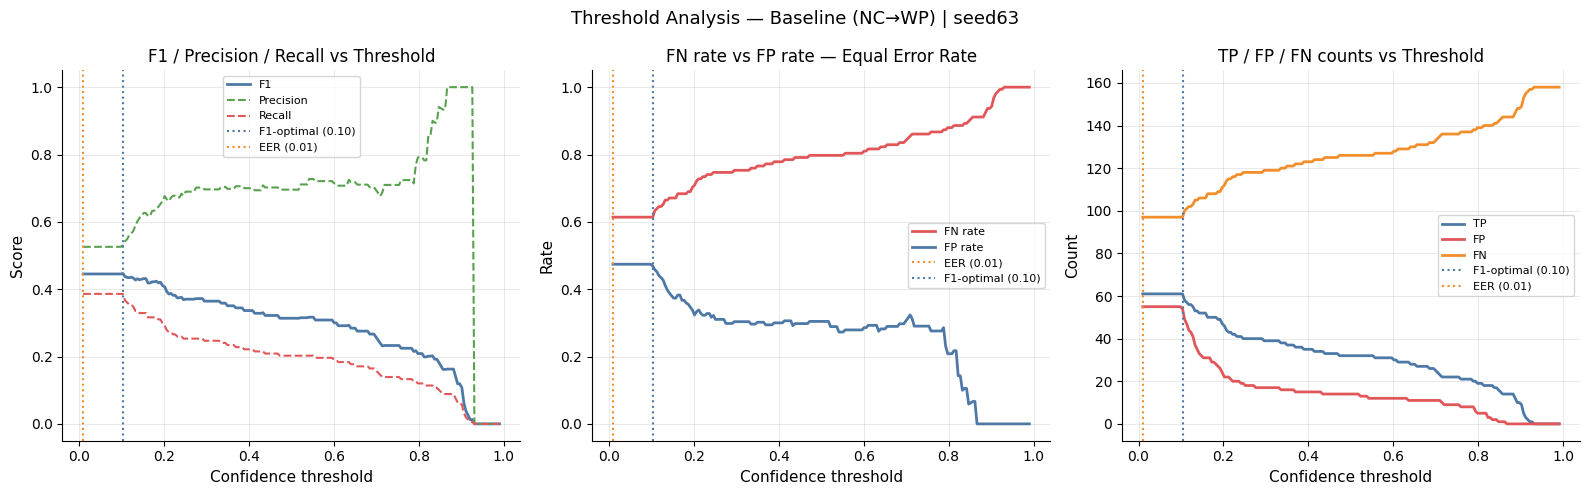

In [28]:
## check the optimal threshold
import numpy as np
import matplotlib.pyplot as plt

# ── Load one evaluation ───────────────────────────────────────────────────────
res    = results_seed63["baseline_SEED63_nms"]
ytrue  = np.array(res.ytrue)
ypred  = np.array(res.ypred)
confs  = np.array([v if v is not None else 0.0 for v in res.confs], dtype=float)
ious   = np.array([v if v is not None else 0.0 for v in res.ious],  dtype=float)

n_gt       = int((ypred == "(none)").sum() + ((ytrue == "Dugong") & (ypred == "Dugong")).sum())
pred_mask  = ypred != "(none)"
thresholds = np.linspace(0.01, 0.99, 200)

# ── Sweep ─────────────────────────────────────────────────────────────────────
records = []
for thresh in thresholds:
    mask = pred_mask & (confs >= thresh)
    tp   = int(((ytrue[mask] == "Dugong") & (ious[mask] >= 0.5)).sum())
    fp   = int((ytrue[mask] == "(none)").sum())
    fn   = int(n_gt - tp)

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    fn_rate   = fn / (n_gt + 1e-9)
    fp_rate   = fp / (mask.sum() + 1e-9) if mask.sum() > 0 else 0.0

    records.append(dict(threshold=thresh, tp=tp, fp=fp, fn=fn,
                        precision=precision, recall=recall,
                        f1=f1, fn_rate=fn_rate, fp_rate=fp_rate))

threshs    = np.array([r["threshold"]  for r in records])
f1s        = np.array([r["f1"]         for r in records])
precisions = np.array([r["precision"]  for r in records])
recalls    = np.array([r["recall"]     for r in records])
fn_rates   = np.array([r["fn_rate"]    for r in records])
fp_rates   = np.array([r["fp_rate"]    for r in records])
tps        = np.array([r["tp"]         for r in records])
fps        = np.array([r["fp"]         for r in records])
fns        = np.array([r["fn"]         for r in records])

# ── Find optimal thresholds ───────────────────────────────────────────────────
best_f1_idx  = np.argmax(f1s)
best_eer_idx = np.argmin(np.abs(fn_rates - fp_rates))

t_f1  = threshs[best_f1_idx]
t_eer = threshs[best_eer_idx]

print("── F1-Optimal ──────────────────────────────────")
print(f"  Threshold : {t_f1:.3f}")
print(f"  F1        : {f1s[best_f1_idx]:.3f}")
print(f"  Precision : {precisions[best_f1_idx]:.3f}")
print(f"  Recall    : {recalls[best_f1_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_f1_idx]} / {fps[best_f1_idx]} / {fns[best_f1_idx]}")

print("\n── Equal Error Rate ────────────────────────────")
print(f"  Threshold : {t_eer:.3f}")
print(f"  FN rate   : {fn_rates[best_eer_idx]:.3f}")
print(f"  FP rate   : {fp_rates[best_eer_idx]:.3f}")
print(f"  Precision : {precisions[best_eer_idx]:.3f}")
print(f"  Recall    : {recalls[best_eer_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_eer_idx]} / {fps[best_eer_idx]} / {fns[best_eer_idx]}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left — F1 curve
ax = axes[0]
ax.plot(threshs, f1s, color="#4e79a7", linewidth=2, label="F1")
ax.plot(threshs, precisions, color="#59a14f", linewidth=1.5,
        linestyle="--", label="Precision")
ax.plot(threshs, recalls, color="#e15759", linewidth=1.5,
        linestyle="--", label="Recall")
ax.axvline(t_f1, color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("F1 / Precision / Recall vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Middle — EER curve
ax = axes[1]
ax.plot(threshs, fn_rates, color="#e15759", linewidth=2, label="FN rate")
ax.plot(threshs, fp_rates, color="#4e79a7", linewidth=2, label="FP rate")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Rate", fontsize=11)
ax.set_title("FN rate vs FP rate — Equal Error Rate", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Right — TP/FP/FN counts
ax = axes[2]
ax.plot(threshs, tps, color="#4e79a7", linewidth=2, label="TP")
ax.plot(threshs, fps, color="#e15759", linewidth=2, label="FP")
ax.plot(threshs, fns, color="#f28e2b", linewidth=2, label="FN")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("TP / FP / FN counts vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Threshold Analysis — Baseline (NC→WP) | seed63", fontsize=13)
plt.tight_layout()
#plt.savefig("threshold_analysis_baseline_seed63.png", dpi=300, bbox_inches="tight")
plt.show()

## compute evaluation

In [29]:
## results seed is loaded from evaluation_results ! 

df_metrics = extract_all_metrics(
    results_seed63,
    seed=63
)
df_metrics

NameError: name 'extract_all_metrics' is not defined

── F1-Optimal ──────────────────────────────────
  Threshold : 0.168
  F1        : 0.564
  Precision : 0.600
  Recall    : 0.532
  TP/FP/FN  : 84 / 56 / 74

── Equal Error Rate ────────────────────────────
  Threshold : 0.133
  FN rate   : 0.449
  FP rate   : 0.460
  Precision : 0.540
  Recall    : 0.551
  TP/FP/FN  : 87 / 74 / 71


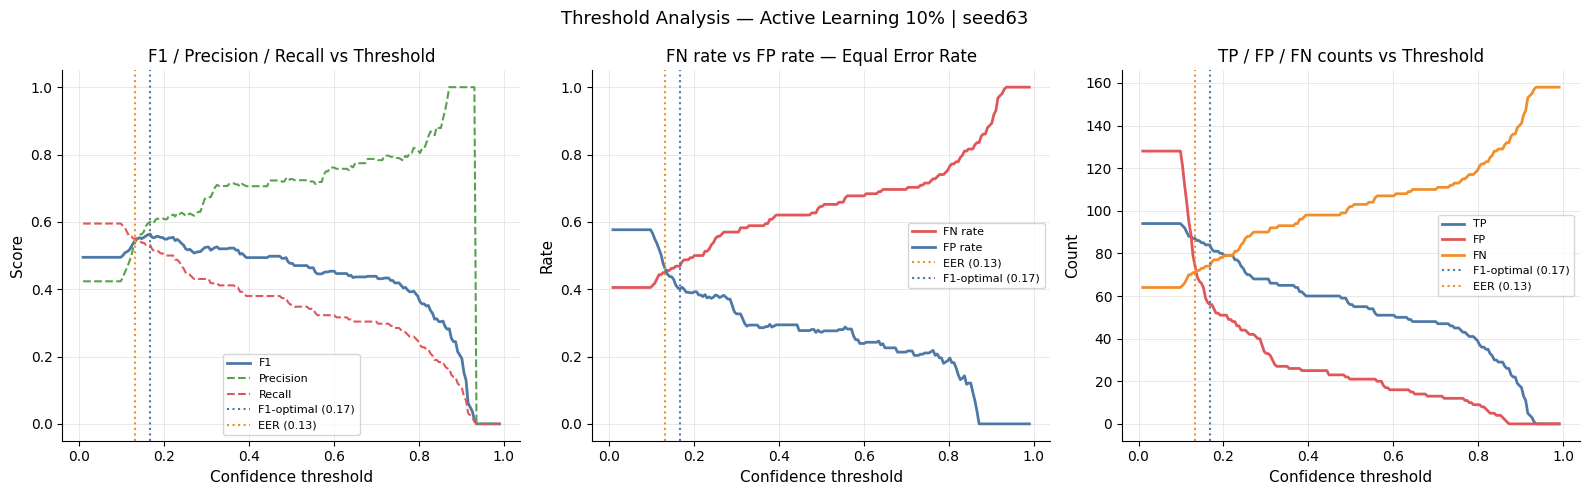

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ── Load one evaluation ───────────────────────────────────────────────────────
res    = results_seed63["ACLR_p25_SEED63_nms"]
ytrue  = np.array(res.ytrue)
ypred  = np.array(res.ypred)
confs  = np.array([v if v is not None else 0.0 for v in res.confs], dtype=float)
ious   = np.array([v if v is not None else 0.0 for v in res.ious],  dtype=float)

n_gt       = int((ypred == "(none)").sum() + ((ytrue == "Dugong") & (ypred == "Dugong")).sum())
pred_mask  = ypred != "(none)"
thresholds = np.linspace(0.01, 0.99, 200)

# ── Sweep ─────────────────────────────────────────────────────────────────────
records = []
for thresh in thresholds:
    mask = pred_mask & (confs >= thresh)
    tp   = int(((ytrue[mask] == "Dugong") & (ious[mask] >= 0.5)).sum())
    fp   = int((ytrue[mask] == "(none)").sum())
    fn   = int(n_gt - tp)

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    fn_rate   = fn / (n_gt + 1e-9)
    fp_rate   = fp / (mask.sum() + 1e-9) if mask.sum() > 0 else 0.0

    records.append(dict(threshold=thresh, tp=tp, fp=fp, fn=fn,
                        precision=precision, recall=recall,
                        f1=f1, fn_rate=fn_rate, fp_rate=fp_rate))

threshs    = np.array([r["threshold"]  for r in records])
f1s        = np.array([r["f1"]         for r in records])
precisions = np.array([r["precision"]  for r in records])
recalls    = np.array([r["recall"]     for r in records])
fn_rates   = np.array([r["fn_rate"]    for r in records])
fp_rates   = np.array([r["fp_rate"]    for r in records])
tps        = np.array([r["tp"]         for r in records])
fps        = np.array([r["fp"]         for r in records])
fns        = np.array([r["fn"]         for r in records])

# ── Find optimal thresholds ───────────────────────────────────────────────────
best_f1_idx  = np.argmax(f1s)
best_eer_idx = np.argmin(np.abs(fn_rates - fp_rates))

t_f1  = threshs[best_f1_idx]
t_eer = threshs[best_eer_idx]

print("── F1-Optimal ──────────────────────────────────")
print(f"  Threshold : {t_f1:.3f}")
print(f"  F1        : {f1s[best_f1_idx]:.3f}")
print(f"  Precision : {precisions[best_f1_idx]:.3f}")
print(f"  Recall    : {recalls[best_f1_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_f1_idx]} / {fps[best_f1_idx]} / {fns[best_f1_idx]}")

print("\n── Equal Error Rate ────────────────────────────")
print(f"  Threshold : {t_eer:.3f}")
print(f"  FN rate   : {fn_rates[best_eer_idx]:.3f}")
print(f"  FP rate   : {fp_rates[best_eer_idx]:.3f}")
print(f"  Precision : {precisions[best_eer_idx]:.3f}")
print(f"  Recall    : {recalls[best_eer_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_eer_idx]} / {fps[best_eer_idx]} / {fns[best_eer_idx]}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left — F1 curve
ax = axes[0]
ax.plot(threshs, f1s, color="#4e79a7", linewidth=2, label="F1")
ax.plot(threshs, precisions, color="#59a14f", linewidth=1.5,
        linestyle="--", label="Precision")
ax.plot(threshs, recalls, color="#e15759", linewidth=1.5,
        linestyle="--", label="Recall")
ax.axvline(t_f1, color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("F1 / Precision / Recall vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Middle — EER curve
ax = axes[1]
ax.plot(threshs, fn_rates, color="#e15759", linewidth=2, label="FN rate")
ax.plot(threshs, fp_rates, color="#4e79a7", linewidth=2, label="FP rate")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Rate", fontsize=11)
ax.set_title("FN rate vs FP rate — Equal Error Rate", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Right — TP/FP/FN counts
ax = axes[2]
ax.plot(threshs, tps, color="#4e79a7", linewidth=2, label="TP")
ax.plot(threshs, fps, color="#e15759", linewidth=2, label="FP")
ax.plot(threshs, fns, color="#f28e2b", linewidth=2, label="FN")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("TP / FP / FN counts vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Threshold Analysis — Active Learning 10% | seed63", fontsize=13)
plt.tight_layout()
#plt.savefig("threshold_analysis_baseline_seed63.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
## results seed is loaded from evaluation_results ! 

df_metrics = extract_all_metrics(
    results_seed63,
    seed=63
)
df_metrics

Seed 63 done — 11 models processed


,seed,eval_key,mAP,mAR,threshold,f1,precision,recall,tp,fp,fn,n_gt
0,63,baseline_SEED63_nms,0.160036,0.233544,0.103568,0.446886,0.530435,0.386076,61,54,97,158
1,63,ACLR_p10_SEED63_nms,0.213113,0.308861,0.113417,0.519878,0.502959,0.537975,85,84,73,158
2,63,ACLR_p25_SEED63_nms,0.242673,0.348734,0.167588,0.563758,0.600000,0.531646,84,56,74,158
3,63,ACLR_p50_SEED63_nms,0.277743,0.381013,0.344874,0.614815,0.741071,0.525316,83,29,75,158
4,63,ACLR_p5_SEED63_nms,0.208259,0.293671,0.133116,0.494845,0.541353,0.455696,72,61,86,158
5,63,ACLR_p75_SEED63_nms,0.246143,0.353797,0.206985,0.586207,0.643939,0.537975,85,47,73,158
6,63,p10_SEED63_nms,0.214278,0.309494,0.113417,0.534591,0.531250,0.537975,85,75,73,158
7,63,p25_SEED63_nms,0.240552,0.340506,0.138040,0.556634,0.569536,0.544304,86,65,72,158
8,63,p50_SEED63_nms,0.252925,0.363291,0.295628,0.566176,0.675439,0.487342,77,37,81,158
9,63,p5_SEED63_nms,0.204735,0.297468,0.113417,0.501548,0.490909,0.512658,81,84,77,158


In [32]:
df_metrics.to_csv('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/results/evaluation/evaluation_all_runs_seed63.csv')

# seed 72

In [53]:
#root_folder_ = '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/'
tesdt = ['/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/NNN_NC_SEED72_augm_0507_1602_conf_10']

In [54]:
check = os.listdir('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72')

In [55]:
check

['NWW_ACLR_partition_75_SEED72_augm_0517_1307',
 'NWW_ACLR_partition_25_SEED72_augm_0514_1802',
 'NWW_ACLR_partition_5_SEED72_augm_0512_1138',
 'NWW_ACLR_partition_10_SEED72_augm_0512_1202',
 'NWW_ACLR_partition_50_SEED72_augm_0518_0613',
 'NWW_partition_10_SEED72_augm_0512_1308',
 'NWW_partition_5_SEED72_augm_0512_1233',
 'NWW_partition_50_SEED72_augm_0517_1625',
 'NWW_partition_75_SEED72_augm_0518_0759',
 'NWW_partition_25_SEED72_augm_0517_1530']

In [40]:
test_view_seed72 = dataset.load_saved_view('wp_test_s72')

In [56]:
## get by seed
sied = 'SEED72'
out_list = []
for line in check:
    for word in line.split('_'):
        if sied == word:
            out_list.append(line)
        else:
            pass

out_list

['NWW_ACLR_partition_75_SEED72_augm_0517_1307',
 'NWW_ACLR_partition_25_SEED72_augm_0514_1802',
 'NWW_ACLR_partition_5_SEED72_augm_0512_1138',
 'NWW_ACLR_partition_10_SEED72_augm_0512_1202',
 'NWW_ACLR_partition_50_SEED72_augm_0518_0613',
 'NWW_partition_10_SEED72_augm_0512_1308',
 'NWW_partition_5_SEED72_augm_0512_1233',
 'NWW_partition_50_SEED72_augm_0517_1625',
 'NWW_partition_75_SEED72_augm_0518_0759',
 'NWW_partition_25_SEED72_augm_0517_1530']

In [ ]:
final_list = 

In [57]:
## reconstruct into fiftyone
root_folder_ = '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72'

list_folders_jj = [os.path.join(root_folder_,l) for l in out_list]
list_folders_jj

['/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72/NWW_ACLR_partition_75_SEED72_augm_0517_1307',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72/NWW_ACLR_partition_25_SEED72_augm_0514_1802',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72/NWW_ACLR_partition_5_SEED72_augm_0512_1138',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72/NWW_ACLR_partition_10_SEED72_augm_0512_1202',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72/NWW_ACLR_partition_50_SEED72_augm_0518_0613',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72/NWW_partition_10_SEED72_augm_0512_1308',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72/NWW_partition_5_SEED72_augm_0512_1233',
 '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72/NWW_partition_50_SEED72_augm_0517_1625',
 '/share/home/e24

In [58]:
def extract_stem(path):
    return Path(path).stem

# import func and reconstruct 

for prediction in list_folders_jj:
    name_field = extract_stem(prediction)
    ## apply non-maximumm supression
    reconstruct_and_nms(
        dataset=dataset,
        predictions_dir=prediction,
        field_name=name_field,
        tile_size=640
    )

2026-05-18 10:07:57.411 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72/NWW_ACLR_partition_75_SEED72_augm_0517_1307'
2026-05-18 10:07:57.451 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 333 JSONs → 100 unique sample stems
2026-05-18 10:07:57.455 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 100 / 2755 samples to JSONs
2026-05-18 10:08:00.579 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NWW_ACLR_partition_75_SEED72_augm_0517_1307_raw' 
2026-05-18 10:08:00.581 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.35) → field 'NWW_ACLR_partition_75_SEED72_augm_0517_1307_nms'


 100% |█████████████████| 100/100 [3.1s elapsed, 0s remaining, 38.4 samples/s]      


2026-05-18 10:08:03.744 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NWW_ACLR_partition_75_SEED72_augm_0517_1307_nms' saved | detections before NMS: 470 | after NMS: 358 | suppressed: 112 (23.8%)
2026-05-18 10:08:03.745 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72/NWW_ACLR_partition_25_SEED72_augm_0514_1802'
2026-05-18 10:08:03.769 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 333 JSONs → 100 unique sample stems
2026-05-18 10:08:03.772 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 100 / 2755 samples to JSONs
2026-05-18 10:08:07.237 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NWW_ACLR_partition_25_SEED72_augm_0514_1802_raw' 
2026-05-18 10:08:07.239 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.35) → field 'NWW

 100% |█████████████████| 100/100 [3.1s elapsed, 0s remaining, 39.1 samples/s]      


2026-05-18 10:08:10.376 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NWW_ACLR_partition_25_SEED72_augm_0514_1802_nms' saved | detections before NMS: 249 | after NMS: 195 | suppressed: 54 (21.7%)
2026-05-18 10:08:10.377 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72/NWW_ACLR_partition_5_SEED72_augm_0512_1138'
2026-05-18 10:08:10.666 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 333 JSONs → 100 unique sample stems
2026-05-18 10:08:10.669 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 100 / 2755 samples to JSONs
2026-05-18 10:08:13.821 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NWW_ACLR_partition_5_SEED72_augm_0512_1138_raw' 
2026-05-18 10:08:13.823 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.35) → field 'NWW_AC

...

2026-05-18 10:08:50.949 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NWW_partition_50_SEED72_augm_0517_1625_nms' saved | detections before NMS: 279 | after NMS: 215 | suppressed: 64 (22.9%)
2026-05-18 10:08:50.950 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72/NWW_partition_75_SEED72_augm_0518_0759'
2026-05-18 10:08:50.977 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 333 JSONs → 100 unique sample stems
2026-05-18 10:08:50.979 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 100 / 2755 samples to JSONs
2026-05-18 10:08:54.765 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NWW_partition_75_SEED72_augm_0518_0759_raw' 
2026-05-18 10:08:54.767 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.35) → field 'NWW_partition_75_SE

 100% |█████████████████| 100/100 [3.7s elapsed, 0s remaining, 29.0 samples/s]      


2026-05-18 10:08:58.460 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NWW_partition_75_SEED72_augm_0518_0759_nms' saved | detections before NMS: 296 | after NMS: 228 | suppressed: 68 (23.0%)
2026-05-18 10:08:58.461 | INFO     | reconstruct:reconstruct_and_nms:352 - Reconstructing raw detections from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/output_inference/seed72/NWW_partition_25_SEED72_augm_0517_1530'
2026-05-18 10:08:58.488 | INFO     | reconstruct:_group_jsons_by_sample:98 - Grouped 333 JSONs → 100 unique sample stems
2026-05-18 10:08:58.490 | INFO     | reconstruct:reconstruct_predictions:280 - Matched 100 / 2755 samples to JSONs
2026-05-18 10:09:02.272 | SUCCESS  | reconstruct:reconstruct_predictions:312 - reconstruct_predictions complete → field 'NWW_partition_25_SEED72_augm_0517_1530_raw' 
2026-05-18 10:09:02.274 | INFO     | reconstruct:reconstruct_and_nms:365 - Running NMS (iou_threshold=0.35) → field 'NWW_partition_25_SE

 100% |█████████████████| 100/100 [3.7s elapsed, 0s remaining, 36.2 samples/s]      


2026-05-18 10:09:06.010 | SUCCESS  | reconstruct:reconstruct_and_nms:398 - reconstruct_and_nms complete → field 'NWW_partition_25_SEED72_augm_0517_1530_nms' saved | detections before NMS: 296 | after NMS: 243 | suppressed: 53 (17.9%)


In [59]:
which_seed = "_SEED72_"
all_fields = dataset.get_field_schema().keys()
seed72_fields = [f for f in all_fields if which_seed in f]

seed72_fields_raw = [f for f in seed72_fields if "raw" in f]
seed72_fields_nms = [f for f in seed72_fields if "nms" in f]
seed72_fields_excluding_evaluation = [
    f for f in seed72_fields if not any(x in f for x in ['tp', 'tn', 'fp','fn'])
]
seed72_fields_excluding_evaluation

['NNN_NC_SEED72_augm_0507_1602_conf_10_raw',
 'NNN_NC_SEED72_augm_0507_1602_conf_10_nms',
 'NNN_NC_SEED72_baseline10_augm_0422_2254_conf_10_raw',
 'NNN_NC_SEED72_baseline10_augm_0422_2254_conf_10_nms',
 'NNN_NC_SEED72_baseline63_augm_0510_1843_conf_10_raw',
 'NNN_NC_SEED72_baseline63_augm_0510_1843_conf_10_nms',
 'NNN_NC_SEED72_baseline72_augm_0511_2138_conf_10_raw',
 'NNN_NC_SEED72_baseline72_augm_0511_2138_conf_10_nms',
 'NWW_ACLR_partition_75_SEED72_augm_0517_1307_raw',
 'NWW_ACLR_partition_75_SEED72_augm_0517_1307_nms',
 'NWW_ACLR_partition_25_SEED72_augm_0514_1802_raw',
 'NWW_ACLR_partition_25_SEED72_augm_0514_1802_nms',
 'NWW_ACLR_partition_5_SEED72_augm_0512_1138_raw',
 'NWW_ACLR_partition_5_SEED72_augm_0512_1138_nms',
 'NWW_ACLR_partition_10_SEED72_augm_0512_1202_raw',
 'NWW_ACLR_partition_10_SEED72_augm_0512_1202_nms',
 'NWW_partition_10_SEED72_augm_0512_1308_raw',
 'NWW_partition_10_SEED72_augm_0512_1308_nms',
 'NWW_partition_5_SEED72_augm_0512_1233_raw',
 'NWW_partition_5_SE

In [60]:
sss_seed72 = select_evaluation_list(
    all_op= seed72_fields_excluding_evaluation,
    nms_or_raw='nms',
     seed_term='SEED72',
    baseline_field='NNN_NC_SEED72_augm_0507_1602_conf_10_raw'
)
sss_seed72

[{'pred_field': 'NNN_NC_SEED72_augm_0507_1602_conf_10_nms',
  'eval_key': 'pSEED72_augm_nms'},
 {'pred_field': 'NNN_NC_SEED72_baseline10_augm_0422_2254_conf_10_nms',
  'eval_key': 'pSEED72_baseline10_nms'},
 {'pred_field': 'NNN_NC_SEED72_baseline63_augm_0510_1843_conf_10_nms',
  'eval_key': 'pSEED72_baseline63_nms'},
 {'pred_field': 'NNN_NC_SEED72_baseline72_augm_0511_2138_conf_10_nms',
  'eval_key': 'pSEED72_baseline72_nms'},
 {'pred_field': 'NWW_ACLR_partition_75_SEED72_augm_0517_1307_nms',
  'eval_key': 'ACLR_p75_SEED72_nms'},
 {'pred_field': 'NWW_ACLR_partition_25_SEED72_augm_0514_1802_nms',
  'eval_key': 'ACLR_p25_SEED72_nms'},
 {'pred_field': 'NWW_ACLR_partition_5_SEED72_augm_0512_1138_nms',
  'eval_key': 'ACLR_p5_SEED72_nms'},
 {'pred_field': 'NWW_ACLR_partition_10_SEED72_augm_0512_1202_nms',
  'eval_key': 'ACLR_p10_SEED72_nms'},
 {'pred_field': 'NWW_partition_10_SEED72_augm_0512_1308_nms',
  'eval_key': 'p10_SEED72_nms'},
 {'pred_field': 'NWW_partition_5_SEED72_augm_0512_1233_n

In [47]:
# check for duplicates
from collections import Counter
pred_fields = [d['pred_field'] for d in sss_seed72]
dups = [k for k, v in Counter(pred_fields).items() if v > 1]

print(f"WARNING: THERE IS DUPLICATED FIELD: {dups}")

In [64]:
# DROP DUPLICATE AND LEAVE BASELINE
seen = {}

for item in sss_seed72:
    key = item['pred_field']
    
    if key not in seen:
        seen[key] = item
    else:
        # if duplicate exists, prefer baseline
        if "baseline" in item['eval_key']:
            seen[key] = item
        elif "baseline" not in seen[key]['eval_key']:
            # neither is baseline → keep first (do nothing)
            pass
        # else: existing is baseline → ignore current duplicate

sss_seed72 = list(seen.values())
sss_seed72

[{'pred_field': 'NNN_NC_SEED72_augm_0507_1602_conf_10_raw',
  'eval_key': 'baseline_SEED72_raw'}]

In [61]:
sss_seed72 = [
 {'pred_field': 'NWW_ACLR_partition_75_SEED72_augm_0517_1307_nms',
  'eval_key': 'ACLR_p75_SEED72_nms'},
 {'pred_field': 'NWW_ACLR_partition_25_SEED72_augm_0514_1802_nms',
  'eval_key': 'ACLR_p25_SEED72_nms'},
 {'pred_field': 'NWW_ACLR_partition_5_SEED72_augm_0512_1138_nms',
  'eval_key': 'ACLR_p5_SEED72_nms'},
 {'pred_field': 'NWW_ACLR_partition_10_SEED72_augm_0512_1202_nms',
  'eval_key': 'ACLR_p10_SEED72_nms'},
 {'pred_field': 'NWW_partition_10_SEED72_augm_0512_1308_nms',
  'eval_key': 'p10_SEED72_nms'},
 {'pred_field': 'NWW_partition_5_SEED72_augm_0512_1233_nms',
  'eval_key': 'p5_SEED72_nms'},
 {'pred_field': 'NWW_partition_50_SEED72_augm_0517_1625_nms',
  'eval_key': 'p50_SEED72_nms'},
 {'pred_field': 'NWW_partition_25_SEED72_augm_0517_1530_nms',
  'eval_key': 'p25_SEED72_nms'},
 {'pred_field': 'NWW_ACLR_partition_50_SEED72_augm_0518_0613_nms',
  'eval_key': 'ACLR_p50_SEED72_nms'},
 {'pred_field': 'NWW_partition_75_SEED72_augm_0518_0759_nms',
  'eval_key': 'p75_SEED72_nms'},
 {'pred_field': 'NNN_NC_SEED72_baseline72_augm_0511_2138_conf_10_nms',
  'eval_key': 'baseline_SEED72_nms'}]

In [ ]:
test_view_seed72 = wp_view.match_tags('test_72')
test_view_seed72

In [62]:

# compute evaluations 
# --- Run evaluations ---
results = {}
for m in sss_seed72:
    results[m["eval_key"]] = test_view_seed72.evaluate_detections(
        m["pred_field"],
        gt_field="ground_truth",
        eval_key=m["eval_key"],
        method="coco",          # COCO-style mAP
        iou=0.5,
        classwise=False,        # single class (dugong), no need to enforce classwise
        compute_mAP=True,
    )

Evaluating detections...
 100% |█████████████████| 100/100 [877.3ms elapsed, 0s remaining, 114.0 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 100/100 [729.1ms elapsed, 0s remaining, 137.2 samples/s]      
Evaluating detections...
 100% |█████████████████| 100/100 [995.9ms elapsed, 0s remaining, 100.4 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 100/100 [638.4ms elapsed, 0s remaining, 156.6 samples/s]      
Evaluating detections...
 100% |█████████████████| 100/100 [736.9ms elapsed, 0s remaining, 135.7 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 100/100 [602.5ms elapsed, 0s remaining, 166.0 samples/s]      
Evaluating detections...
 100% |█████████████████| 100/100 [738.6ms elapsed, 0s remaining, 135.4 samples/s]      
Performing IoU sweep...
 100% |█████████████████| 100/100 [610.5ms elapsed, 0s remaining, 163.8 samples/s]      
Evaluating detections...
 100% |█████████████████| 100/100 [790.6ms elapsed, 0s remaining, 1

In [63]:
## reload evaluations 
# Reload evaluation
results_seed72 = {}
for model in sss_seed72:
    results_seed72[model['eval_key']] = dataset.load_evaluation_results(model['eval_key'])
results_seed72

{'ACLR_p75_SEED72_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b54951510>,
 'ACLR_p25_SEED72_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b5476be10>,
 'ACLR_p5_SEED72_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b0bd51510>,
 'ACLR_p10_SEED72_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b541a5f90>,
 'p10_SEED72_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b55570090>,
 'p5_SEED72_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b541a6790>,
 'p50_SEED72_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b54a2c2d0>,
 'p25_SEED72_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b5027abd0>,
 'ACLR_p50_SEED72_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b54a2edd0>,
 'p75_SEED72_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3c98d52190>,
 'baseline_SEED72_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7f3b50279f50>}

In [64]:
## results seed is loaded from evaluation_results ! 

df_metrics = extract_all_metrics(
    results_seed72,
    seed=72
)
df_metrics

Seed 72 done — 11 models processed


,seed,eval_key,mAP,mAR,threshold,f1,precision,recall,tp,fp,fn,n_gt
0,72,ACLR_p75_SEED72_nms,0.410905,0.440964,0.226683,0.684211,0.910000,0.548193,91,9,75,166
1,72,ACLR_p25_SEED72_nms,0.427268,0.472892,0.182362,0.666667,0.897959,0.530120,88,10,78,166
2,72,ACLR_p5_SEED72_nms,0.363672,0.413855,0.133116,0.638298,0.775862,0.542169,90,26,76,166
3,72,ACLR_p10_SEED72_nms,0.394453,0.448795,0.123266,0.671186,0.767442,0.596386,99,30,67,166
4,72,p10_SEED72_nms,0.403085,0.454819,0.138040,0.675676,0.769231,0.602410,100,30,66,166
5,72,p5_SEED72_nms,0.384070,0.429518,0.157739,0.664336,0.791667,0.572289,95,25,71,166
6,72,p50_SEED72_nms,0.407491,0.443373,0.157739,0.666667,0.836364,0.554217,92,18,74,166
7,72,p25_SEED72_nms,0.400226,0.448795,0.147889,0.657439,0.772358,0.572289,95,28,71,166
8,72,ACLR_p50_SEED72_nms,0.420848,0.462048,0.187286,0.683636,0.862385,0.566265,94,15,72,166
9,72,p75_SEED72_nms,0.407793,0.444578,0.192211,0.671587,0.866667,0.548193,91,14,75,166


In [65]:
df_metrics.to_csv('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/results/evaluation/evaluation_all_runs_seed72.csv')

── F1-Optimal ──────────────────────────────────
  Threshold : 0.118
  F1        : 0.158
  Precision : 0.166
  Recall    : 0.151
  TP/FP/FN  : 25 / 126 / 141

── Equal Error Rate ────────────────────────────
  Threshold : 0.113
  FN rate   : 0.843
  FP rate   : 0.843
  Precision : 0.157
  Recall    : 0.157
  TP/FP/FN  : 26 / 140 / 140


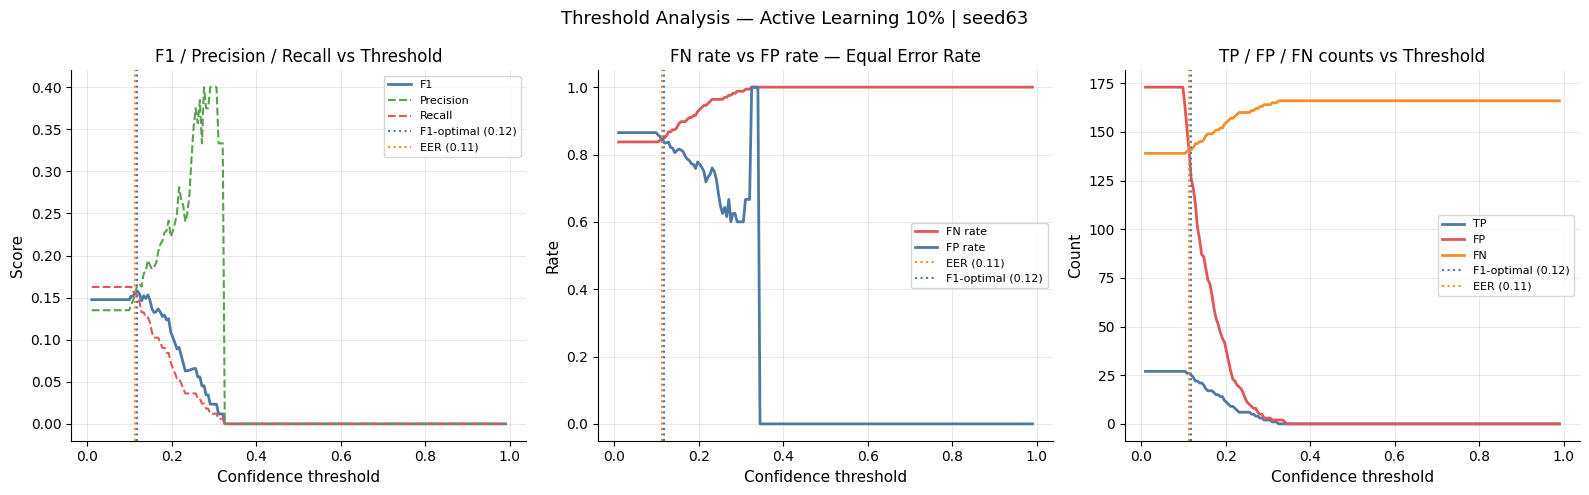

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# ── Load one evaluation ───────────────────────────────────────────────────────
res    = results_seed72["baseline_SEED72_raw"]
ytrue  = np.array(res.ytrue)
ypred  = np.array(res.ypred)
confs  = np.array([v if v is not None else 0.0 for v in res.confs], dtype=float)
ious   = np.array([v if v is not None else 0.0 for v in res.ious],  dtype=float)

n_gt       = int((ypred == "(none)").sum() + ((ytrue == "Dugong") & (ypred == "Dugong")).sum())
pred_mask  = ypred != "(none)"
thresholds = np.linspace(0.01, 0.99, 200)

# ── Sweep ─────────────────────────────────────────────────────────────────────
records = []
for thresh in thresholds:
    mask = pred_mask & (confs >= thresh)
    tp   = int(((ytrue[mask] == "Dugong") & (ious[mask] >= 0.5)).sum())
    fp   = int((ytrue[mask] == "(none)").sum())
    fn   = int(n_gt - tp)

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    fn_rate   = fn / (n_gt + 1e-9)
    fp_rate   = fp / (mask.sum() + 1e-9) if mask.sum() > 0 else 0.0

    records.append(dict(threshold=thresh, tp=tp, fp=fp, fn=fn,
                        precision=precision, recall=recall,
                        f1=f1, fn_rate=fn_rate, fp_rate=fp_rate))

threshs    = np.array([r["threshold"]  for r in records])
f1s        = np.array([r["f1"]         for r in records])
precisions = np.array([r["precision"]  for r in records])
recalls    = np.array([r["recall"]     for r in records])
fn_rates   = np.array([r["fn_rate"]    for r in records])
fp_rates   = np.array([r["fp_rate"]    for r in records])
tps        = np.array([r["tp"]         for r in records])
fps        = np.array([r["fp"]         for r in records])
fns        = np.array([r["fn"]         for r in records])

# ── Find optimal thresholds ───────────────────────────────────────────────────
best_f1_idx  = np.argmax(f1s)
best_eer_idx = np.argmin(np.abs(fn_rates - fp_rates))

t_f1  = threshs[best_f1_idx]
t_eer = threshs[best_eer_idx]

print("── F1-Optimal ──────────────────────────────────")
print(f"  Threshold : {t_f1:.3f}")
print(f"  F1        : {f1s[best_f1_idx]:.3f}")
print(f"  Precision : {precisions[best_f1_idx]:.3f}")
print(f"  Recall    : {recalls[best_f1_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_f1_idx]} / {fps[best_f1_idx]} / {fns[best_f1_idx]}")

print("\n── Equal Error Rate ────────────────────────────")
print(f"  Threshold : {t_eer:.3f}")
print(f"  FN rate   : {fn_rates[best_eer_idx]:.3f}")
print(f"  FP rate   : {fp_rates[best_eer_idx]:.3f}")
print(f"  Precision : {precisions[best_eer_idx]:.3f}")
print(f"  Recall    : {recalls[best_eer_idx]:.3f}")
print(f"  TP/FP/FN  : {tps[best_eer_idx]} / {fps[best_eer_idx]} / {fns[best_eer_idx]}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left — F1 curve
ax = axes[0]
ax.plot(threshs, f1s, color="#4e79a7", linewidth=2, label="F1")
ax.plot(threshs, precisions, color="#59a14f", linewidth=1.5,
        linestyle="--", label="Precision")
ax.plot(threshs, recalls, color="#e15759", linewidth=1.5,
        linestyle="--", label="Recall")
ax.axvline(t_f1, color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("F1 / Precision / Recall vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Middle — EER curve
ax = axes[1]
ax.plot(threshs, fn_rates, color="#e15759", linewidth=2, label="FN rate")
ax.plot(threshs, fp_rates, color="#4e79a7", linewidth=2, label="FP rate")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Rate", fontsize=11)
ax.set_title("FN rate vs FP rate — Equal Error Rate", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

# Right — TP/FP/FN counts
ax = axes[2]
ax.plot(threshs, tps, color="#4e79a7", linewidth=2, label="TP")
ax.plot(threshs, fps, color="#e15759", linewidth=2, label="FP")
ax.plot(threshs, fns, color="#f28e2b", linewidth=2, label="FN")
ax.axvline(t_f1,  color="#4e79a7", linewidth=1.5, linestyle=":",
           label=f"F1-optimal ({t_f1:.2f})")
ax.axvline(t_eer, color="#f28e2b", linewidth=1.5, linestyle=":",
           label=f"EER ({t_eer:.2f})")
ax.set_xlabel("Confidence threshold", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("TP / FP / FN counts vs Threshold", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Threshold Analysis — Active Learning 10% | seed63", fontsize=13)
plt.tight_layout()
#plt.savefig("threshold_analysis_baseline_seed63.png", dpi=300, bbox_inches="tight")
plt.show()

In [74]:
test_view_seed72.distinct('stratify_key')

['WP_MANTASANDY_MANTASANDY_M5', 'WP_UM_UM_M2', 'WP_UM_UM_M3', 'WP_UM_UM_M6']

In [75]:
import safetensors.torch as st
from pathlib import Path

ckpt = Path("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/checkpoints/NNN_NC_SEED63_augm_0506_0140/hf_export")
tensors = st.load_file(str(ckpt / "model.safetensors"))
print("enc_score_head:", tensors["model.enc_score_head.weight"].shape)
# Expected: torch.Size([1, 256])
# If [80, 256] → corrupted, explains everything

enc_score_head: torch.Size([1, 256])
